In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Lasso
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 12


In [92]:
df = pd.read_csv(
    '/kaggle/input/datasets/lkssaa862/mpi-roof-2025-1/mpi_roof_2025 (1).csv', 
    parse_dates=['Date Time'], 
    index_col='Date Time',
    dayfirst=True
)
#print(df['rho (g/m**3)'].head(100))
print(df.head())
print(f"с {df.index.min()} по {df.index.max()}")
print(df.shape)

if not isinstance(df.index, pd.DatetimeIndex):
    df.index = pd.to_datetime(df.index, dayfirst=True)
df.sort_index(inplace=True)

cols_to_drop = ['Tpot (K)', 'Tdew (degC)', 'VPmax (mbar)', 'VPact (mbar)', 
                'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 
                'max. wv (m/s)', 'raining (s)', 'max. PAR (�mol/m�/s)', 
                'Tlog (degC)', 'PAR (�mol/m�/s)', 'wd (deg)']

#cols_to_drop_existing = [c for c in cols_to_drop if c in df.columns]
df.drop(columns=cols_to_drop, inplace=True)
print(f"{df.isnull().sum().sum()} пропусков") 
df.fillna(method='ffill', inplace=True)
print(f"{df.isnull().sum().sum()} пропусков") 
rh = df['rh (%)']

                     p (mbar)  T (degC)  Tpot (K)  Tdew (degC)  rh (%)  \
Date Time                                                                
2025-01-01 00:10:00    997.30     -1.56    271.80        -2.97    90.0   
2025-01-01 00:20:00    997.05     -0.90    272.48        -2.66    87.8   
2025-01-01 00:30:00    996.96     -0.51    272.88        -2.44    86.7   
2025-01-01 00:40:00    996.77     -0.27    273.14        -2.26    86.3   
2025-01-01 00:50:00    996.62     -0.09    273.33        -2.14    86.0   

                     VPmax (mbar)  VPact (mbar)  VPdef (mbar)  sh (g/kg)  \
Date Time                                                                  
2025-01-01 00:10:00          5.45          4.90          0.54       3.06   
2025-01-01 00:20:00          5.72          5.02          0.70       3.14   
2025-01-01 00:30:00          5.89          5.10          0.78       3.19   
2025-01-01 00:40:00          5.99          5.17          0.82       3.23   
2025-01-01 00:50:00      

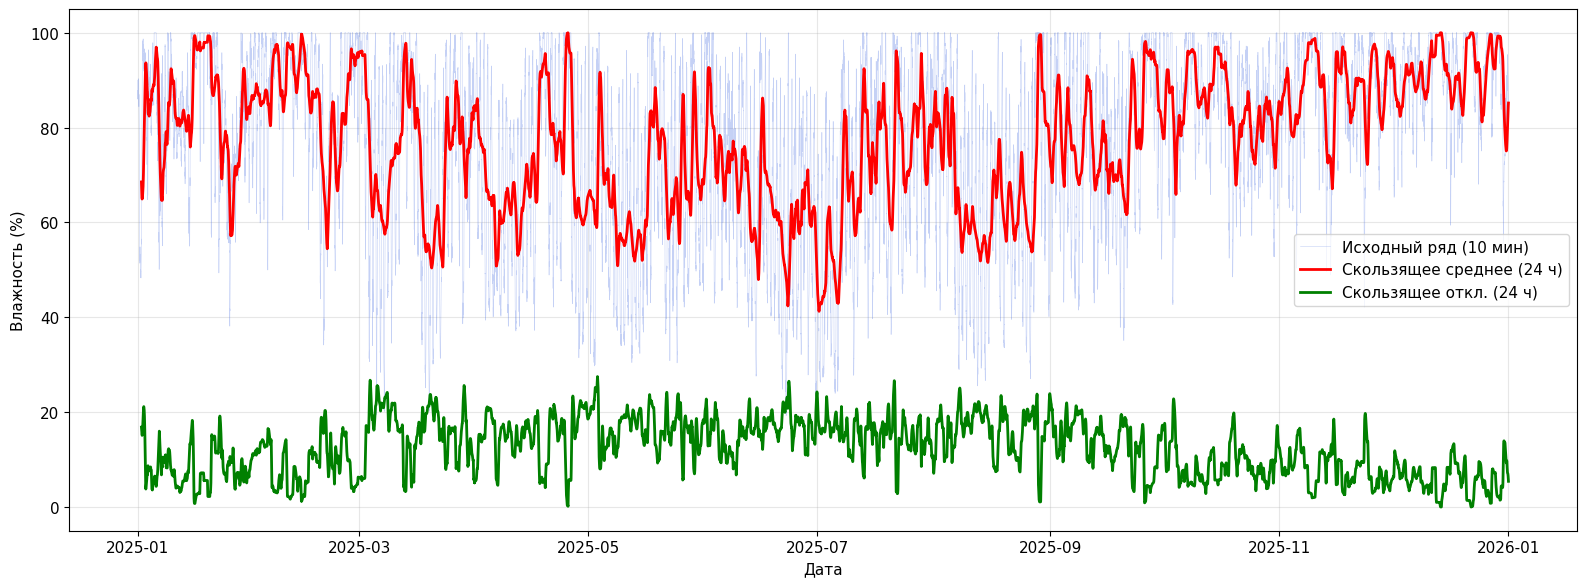

In [93]:
fig, ax = plt.subplots(figsize=(16, 6))
rolling_mean = rh.rolling(window=144).mean()
rolling_std  = rh.rolling(window=144).std()

ax.plot(rh, color='royalblue', alpha=0.3, linewidth=0.4, label='Исходный ряд (10 мин)')
ax.plot(rolling_mean, color='red', linewidth=2, label='Скользящее среднее (24 ч)')
ax.plot(rolling_std, color='green', linewidth=2, label='Скользящее откл. (24 ч)')

adf_result = adfuller(rh.dropna(), autolag='AIC')
p_val = adf_result[1]
ax.set_ylabel('Влажность (%)'); ax.set_xlabel('Дата')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

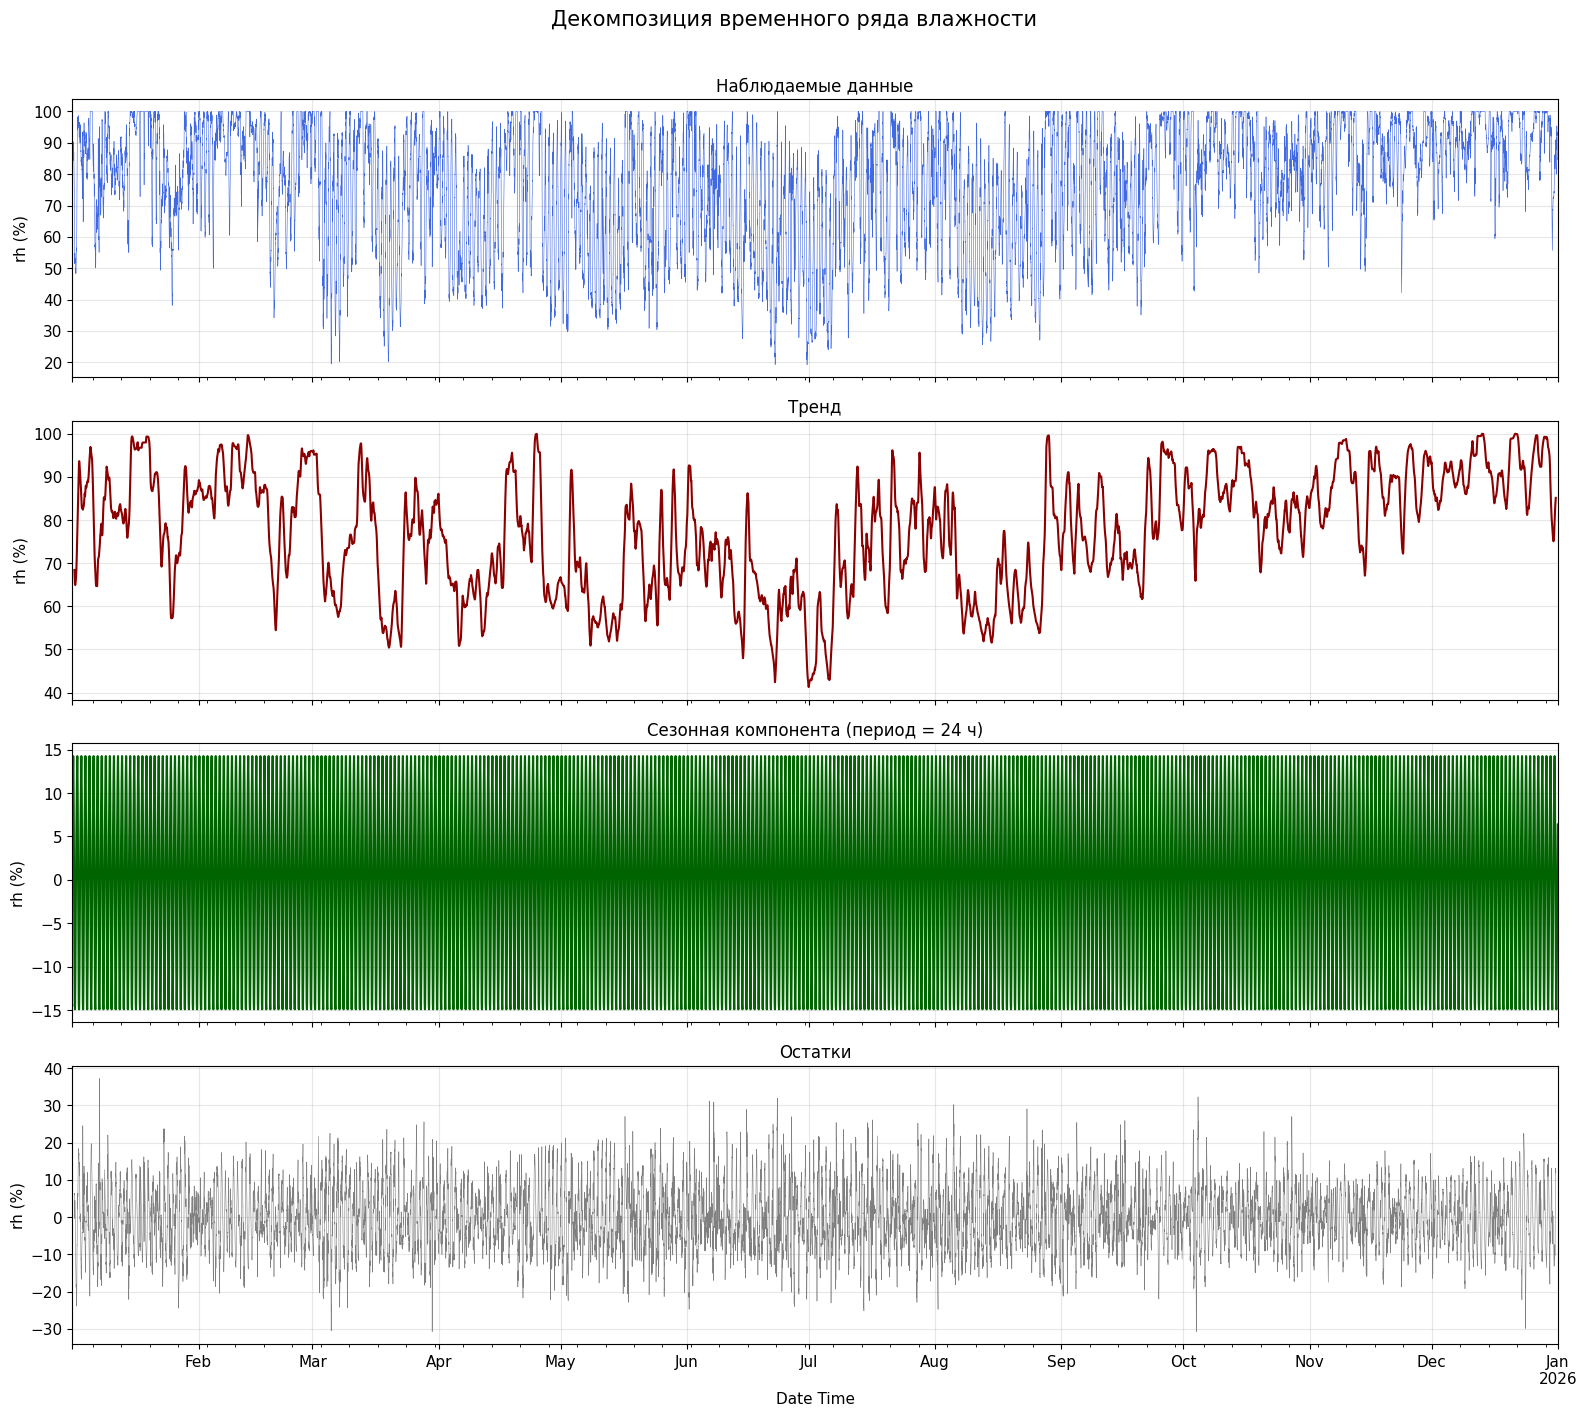

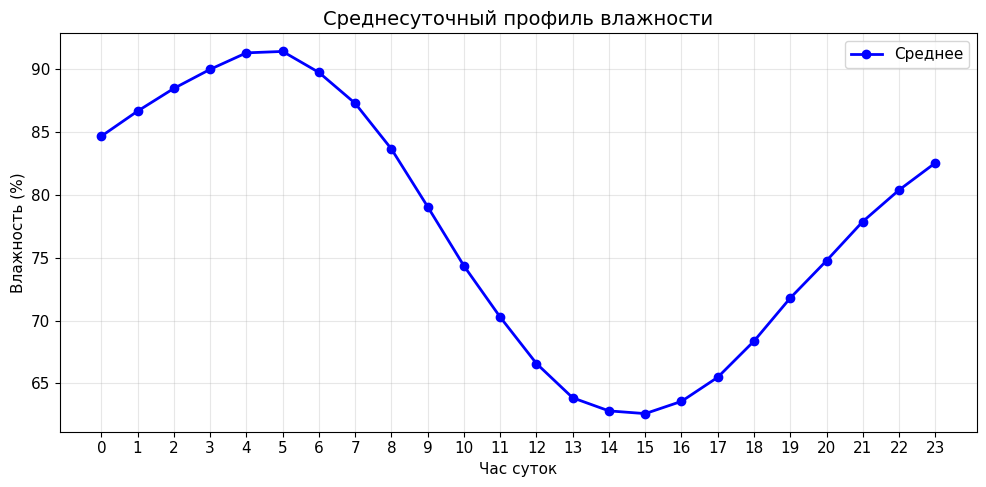

In [94]:
decomp = seasonal_decompose(rh.dropna(), model='additive', period=144)

fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)
decomp.observed.plot(ax=axes[0], title='Наблюдаемые данные', color='royalblue', linewidth=0.4)
decomp.trend.plot(ax=axes[1], title='Тренд', color='darkred')
decomp.seasonal.plot(ax=axes[2], title='Сезонная компонента (период = 24 ч)', color='darkgreen')
decomp.resid.plot(ax=axes[3], title='Остатки', color='gray', linewidth=0.4)
for ax in axes:
    ax.set_ylabel('rh (%)'); ax.grid(True, alpha=0.3)
plt.suptitle('Декомпозиция временного ряда влажности', fontsize=15, y=1.01)
plt.tight_layout(); plt.show()

# Среднесуточный профиль
fig, ax = plt.subplots(figsize=(10, 5))
hourly_profile = rh.groupby(rh.index.hour).agg(['mean', 'std'])
ax.plot(hourly_profile.index, hourly_profile['mean'], 'b-o', linewidth=2, label='Среднее')
ax.set_title('Среднесуточный профиль влажности', fontsize=14)
ax.set_xlabel('Час суток'); ax.set_ylabel('Влажность (%)')
ax.set_xticks(range(24)); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

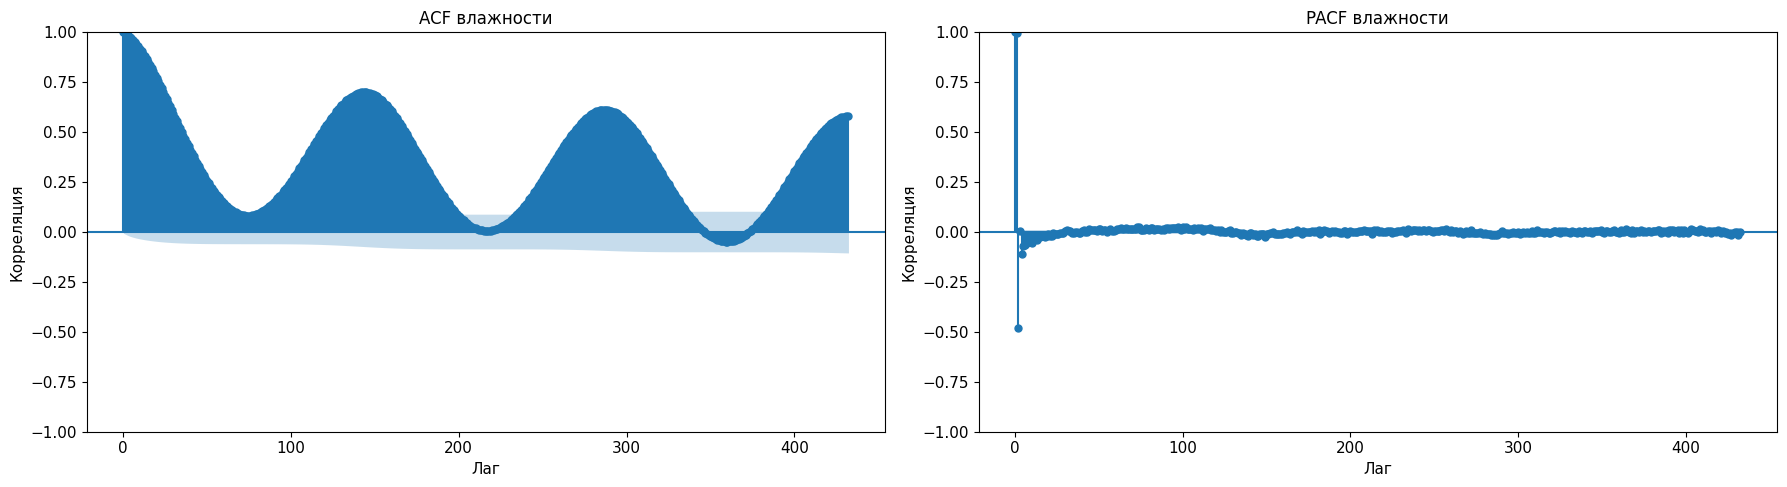

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
plot_acf(rh.dropna(), lags=432, ax=axes[0], title='ACF влажности')
plot_pacf(rh.dropna(), lags=432, ax=axes[1], title='PACF влажности')
for ax in axes:
    ax.set_xlabel('Лаг'); ax.set_ylabel('Корреляция')
plt.tight_layout(); plt.show()


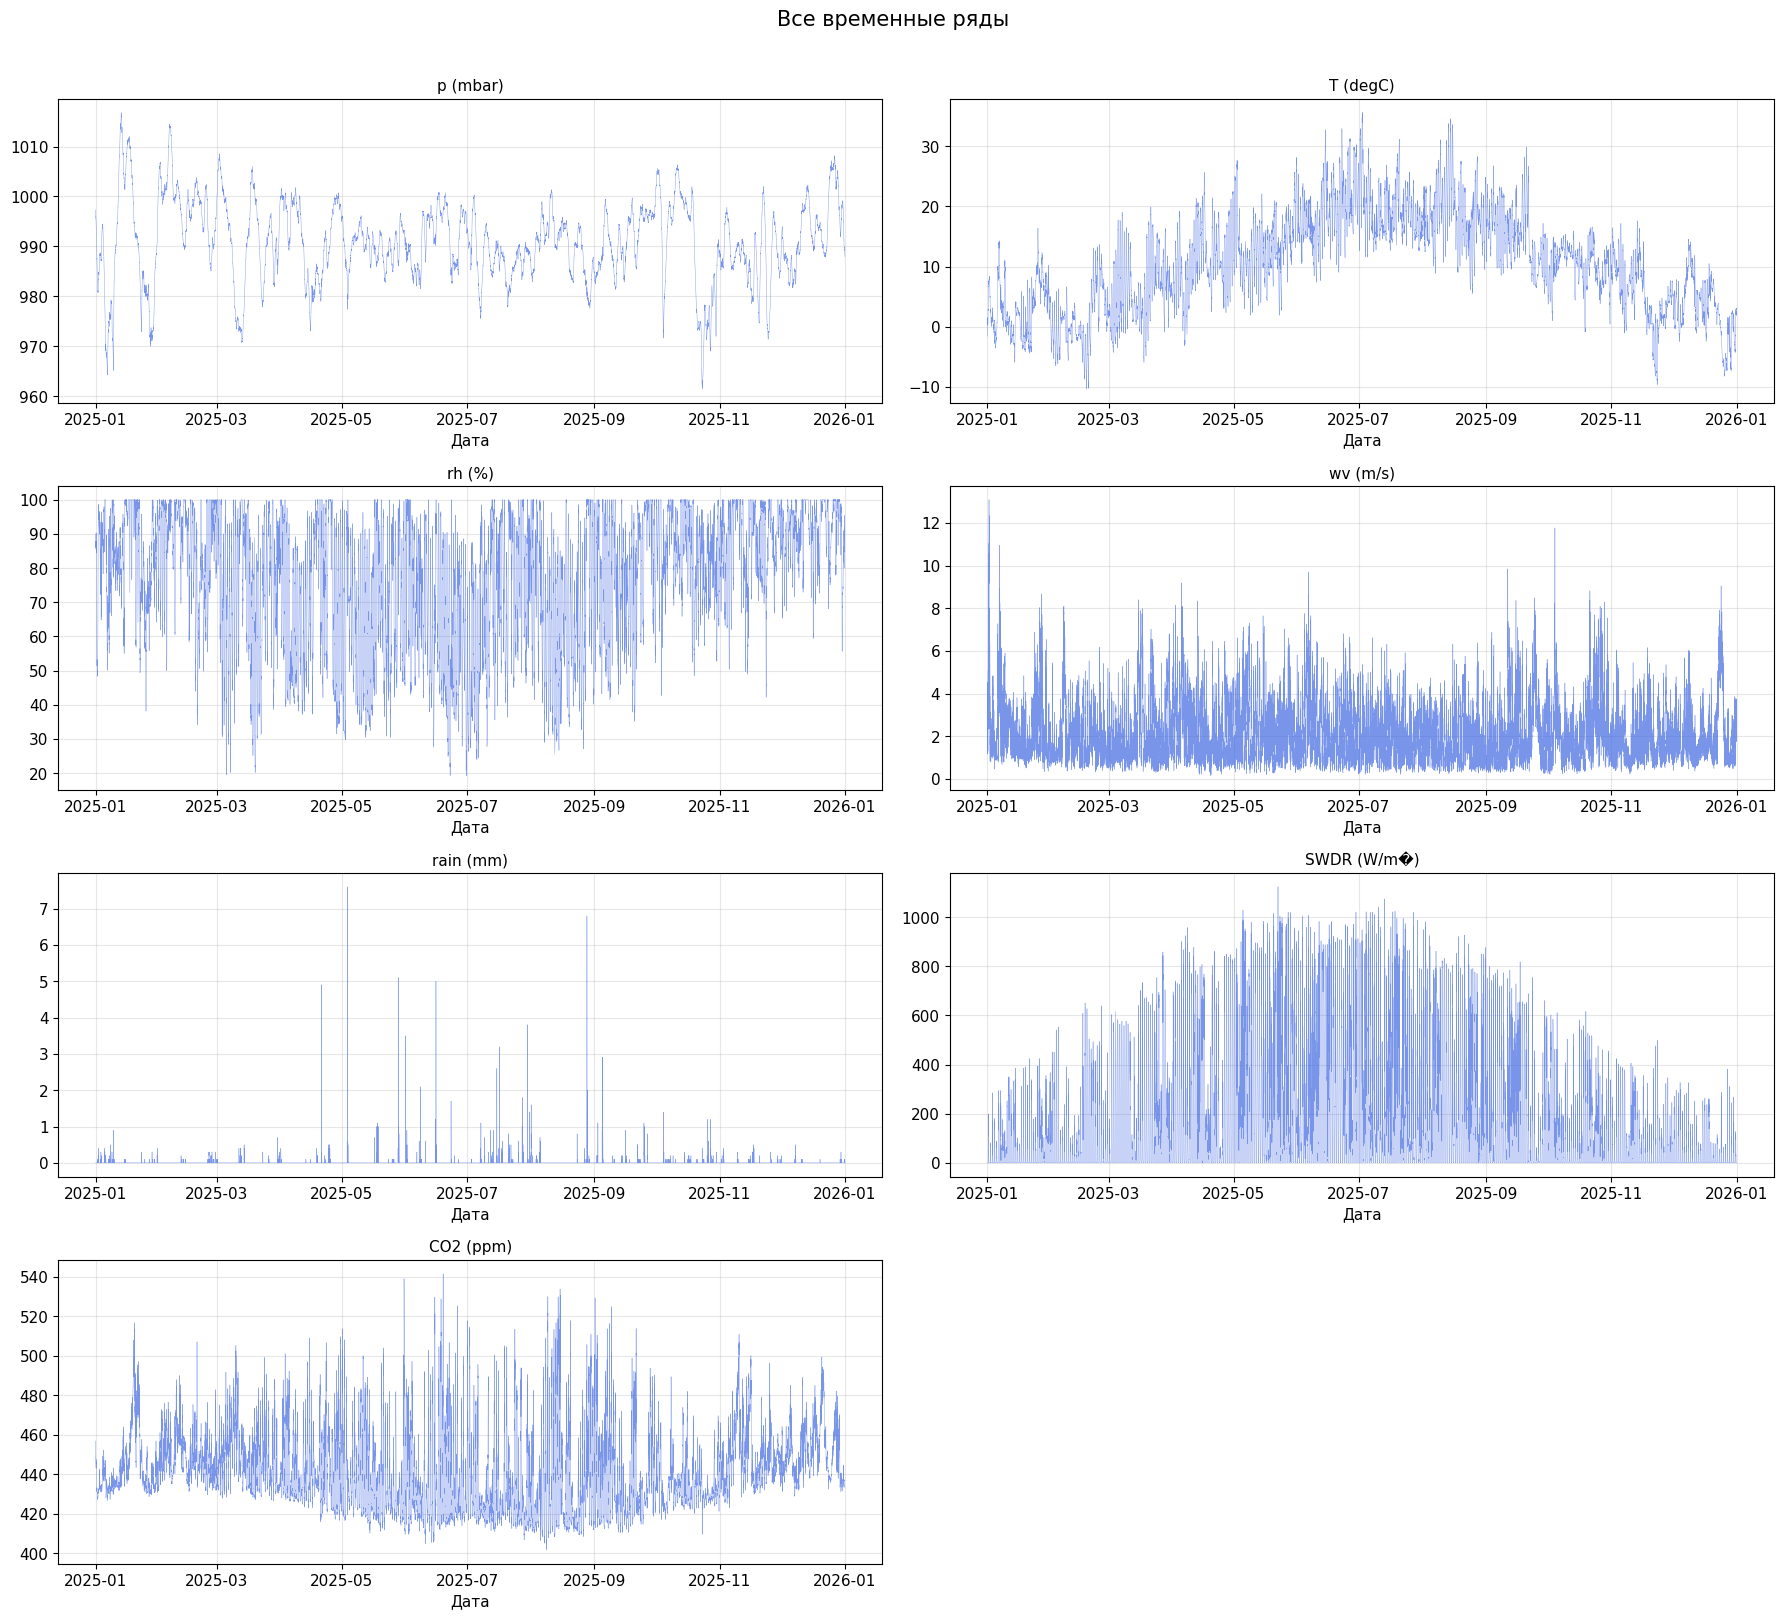

In [96]:
cols_plot = df.columns.tolist()
n = len(cols_plot)
ncols_fig = 2
nrows_fig = (n + 1) // 2
fig, axes = plt.subplots(nrows_fig, ncols_fig, figsize=(18, 4 * nrows_fig))
axes = axes.flatten()
for i, col in enumerate(cols_plot):
    axes[i].plot(df.index, df[col], linewidth=0.3, alpha=0.7, color='royalblue')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('Дата'); axes[i].grid(True, alpha=0.3)
for j in range(n, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Все временные ряды', fontsize=15, y=1.01)
plt.tight_layout(); plt.show()

Выбросов rh: 2 (0.00%)
Границы: [19.4, 100.0]%
Среднее: 77.4%  Медиана: 81.6%  Стд: 19.1%

Корреляции с rh (%):
  CO2 (ppm)           : +0.560
  rain (mm)           : +0.075
  p (mbar)            : +0.040
  wv (m/s)            : -0.348
  SWDR (W/m�)         : -0.585
  T (degC)            : -0.623


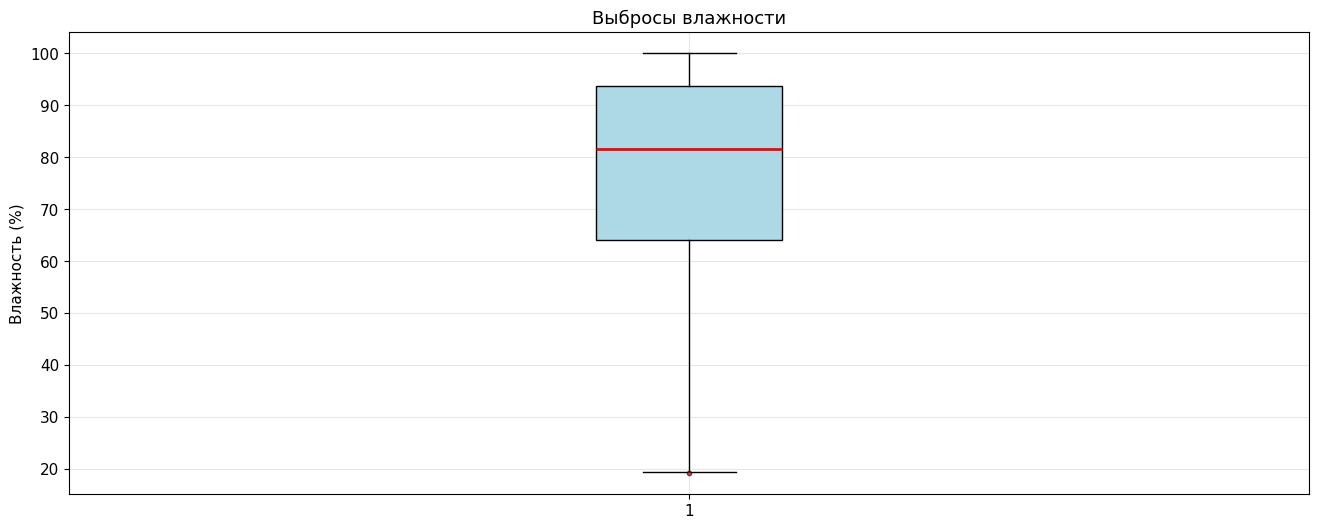

In [97]:
fig, ax = plt.subplots(figsize=(16, 6))

bp1 = ax.boxplot(rh.dropna(), vert=True, patch_artist=True,
                       boxprops=dict(facecolor='lightblue'),
                       medianprops=dict(color='red', linewidth=2),
                       flierprops=dict(marker='o', markerfacecolor='red', markersize=3, alpha=0.4))
ax.set_title('Выбросы влажности', fontsize=13)
ax.set_ylabel('Влажность (%)'); ax.grid(True, alpha=0.3)

# Статистика
Q1, Q3 = rh.quantile(0.25), rh.quantile(0.75)
IQR = Q3 - Q1
lb, ub = Q1 - 1.5 * IQR, min(Q3 + 1.5 * IQR, 100)
outliers = rh[(rh < lb) | (rh > ub)]
print(f"Выбросов rh: {len(outliers)} ({len(outliers)/len(rh)*100:.2f}%)")
print(f"Границы: [{lb:.1f}, {ub:.1f}]%")
print(f"Среднее: {rh.mean():.1f}%  Медиана: {rh.median():.1f}%  Стд: {rh.std():.1f}%")


print("\nКорреляции с rh (%):")
corr = df.corr()['rh (%)'].sort_values(ascending=False)
for v, c in corr.items():
    if v != 'rh (%)':
        print(f"  {v:20s}: {c:+.3f}")

In [98]:
data = df.copy()


for lag in [1, 2, 3, 6, 12, 18, 36, 72, 144]:
    data[f'rh_lag_{lag}'] = data['rh (%)'].shift(lag)
for lag in [1, 6, 36, 72]:
    data[f'temp_lag_{lag}'] = data['T (degC)'].shift(lag)
for lag in [1, 6, 36]:
    data[f'press_lag_{lag}'] = data['p (mbar)'].shift(lag)
    data[f'wind_lag_{lag}']  = data['wv (m/s)'].shift(lag)
for lag in [6, 36, 72]:
    data[f'swdr_lag_{lag}'] = data['SWDR (W/m�)'].shift(lag)


for w in [6, 36, 144]:
    data[f'rh_rm_{w}']   = data['rh (%)'].rolling(w).mean()
    data[f'rh_rstd_{w}']  = data['rh (%)'].rolling(w).std()
    data[f'temp_rm_{w}']  = data['T (degC)'].rolling(w).mean()

for d in [6, 36, 144]:
    data[f'rh_diff_{d}'] = data['rh (%)'].diff(d)


data['hour']      = data.index.hour
data['hour_sin']  = np.sin(2 * np.pi * data['hour'] / 24)
data['hour_cos']  = np.cos(2 * np.pi * data['hour'] / 24)
data['doy']       = data.index.dayofyear
data['doy_sin']   = np.sin(2 * np.pi * data['doy'] / 365)
data['doy_cos']   = np.cos(2 * np.pi * data['doy'] / 365)


data['Target_+1h'] = data['rh (%)'].shift(-6)
data.dropna(inplace=True)

feature_cols = [c for c in data.columns if c not in ['Target_+1h', 'rh (%)', 'hour', 'doy']]
X = data[feature_cols]
y = data['Target_+1h']

print(f"\nПризнаков: {len(feature_cols)}, строк: {len(data)}")

split_idx = int(len(data) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

rh_test_true = data['rh (%)'].iloc[split_idx:]

print(f"Обучение: {len(X_train)} | Тест: {len(X_test)}")

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)


Признаков: 44, строк: 52410
Обучение: 41928 | Тест: 10482


In [99]:
results = {}

print("Обучение Lasso...")
lasso = Lasso(alpha=0.01, max_iter=3000)
lasso.fit(X_train_s, y_train)
pred_lasso = lasso.predict(X_test_s)
results['Lasso'] = {'pred_1h': pred_lasso}

print("Обучение Random Forest...")
rf = RandomForestRegressor(n_estimators=50, max_depth=12, min_samples_split=10, 
                           min_samples_leaf=5, random_state=42, n_jobs=-1)
rf.fit(X_train_s, y_train)
pred_rf = rf.predict(X_test_s)
results['Random Forest'] = {'pred_1h': pred_rf}

print("Обучение LSTM...")
SEQ = 12 

def roll(X, Y, sl=SEQ):
    X_seq = np.array([X[i:i+sl] for i in range(len(X) - sl)], dtype=np.float32)
    Y_seq = np.array([Y[i+sl] for i in range(len(Y) - sl)], dtype=np.float32)
    return X_seq, Y_seq

X_tr_seq, y_tr_seq = roll(X_train_s, y_train.values)
X_te_seq, y_te_seq = roll(X_test_s,  y_test.values)
dates_seq = y_test.index[SEQ:]

lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ, X_tr_seq.shape[2])),
    Dropout(0.2),
    LSTM(32, return_sequences=False), 
    Dropout(0.2),
    Dense(1)
])
lstm.compile(optimizer='adam', loss='mse')
lstm.fit(X_tr_seq, y_tr_seq, 
         epochs=15, 
         batch_size=32, 
         validation_split=0.1,
         callbacks=[EarlyStopping(patience=5, restore_best_weights=True)], 
         verbose=1)
pred_lstm = lstm.predict(X_te_seq, verbose=0).flatten()
results['LSTM'] = {'pred_1h': pred_lstm}

print("Обучение GRU...")
gru = Sequential([
    GRU(64, return_sequences=True, input_shape=(SEQ, X_tr_seq.shape[2])),
    Dropout(0.2),
    GRU(32, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])
gru.compile(optimizer='adam', loss='mse')
gru.fit(X_tr_seq, y_tr_seq, 
        epochs=15, 
        batch_size=32, 
        validation_split=0.1,
        callbacks=[EarlyStopping(patience=5, restore_best_weights=True)], 
        verbose=1)
pred_gru = gru.predict(X_te_seq, verbose=0).flatten()
results['GRU'] = {'pred_1h': pred_gru}


Обучение Lasso...
Обучение Random Forest...
Обучение LSTM...
Epoch 1/15
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - loss: 2725.8931 - val_loss: 2338.3281
Epoch 2/15
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 799.0370 - val_loss: 835.9158
Epoch 3/15
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 240.3236 - val_loss: 178.3747
Epoch 4/15
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 102.3022 - val_loss: 56.3476
Epoch 5/15
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 71.2321 - val_loss: 23.9856
Epoch 6/15
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 71.0524 - val_loss: 34.1454
Epoch 7/15
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 64.6897 - val_loss: 33.4118
Epoch 8/15
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 61.8419 - val_loss: 41.4836
Epoch 9/15
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 60.2478 - val_loss: 33.4130
Epoch 10/15
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 59.5965 - val_loss: 18.9543
Epoch 11/

In [100]:
rang = 24
step = 6 

for name, res in results.items():
    if name in ['Lasso', 'Random Forest']:
        preds = res['pred_1h']
        true_rh = rh_test_true.values
        dates = y_test.index
    else:
        preds = res['pred_1h']
        true_rh = rh_test_true.values[SEQ:]
        dates = dates_seq
    
    max_len = len(preds) - (rang * step)
    pred_24h = np.zeros((max_len, rang))
    true_24h = np.zeros((max_len, rang))
    
    for h in range(rang):
        shift = (h + 1) * step
        pred_24h[:, h] = preds[h * step : max_len + h * step]
        true_24h[:, h] = true_rh[shift : max_len + shift]
        
    res['pred_24h'] = pred_24h
    res['true_24h'] = true_24h
    res['dates'] = dates[:max_len]
    
    mae_h, rmse_h, r2_h = [], [], []
    for h_idx in range(rang):
        mae_h.append(mean_absolute_error(true_24h[:, h_idx], pred_24h[:, h_idx]))
        rmse_h.append(np.sqrt(mean_squared_error(true_24h[:, h_idx], pred_24h[:, h_idx])))
        r2_h.append(r2_score(true_24h[:, h_idx], pred_24h[:, h_idx]))
    res['mae'] = mae_h; res['rmse'] = rmse_h; res['r2'] = r2_h

In [101]:
metrics_data = []
for name, res in results.items():
    metrics_data.append({'Модель': name, 'MAE (+1ч)': res['mae'][0], 'R² (+1ч)': res['r2'][23]})
res_df = pd.DataFrame(metrics_data).sort_values('MAE (+1ч)')
print(res_df.to_string(index=False))

       Модель  MAE (+1ч)  R² (+1ч)
Random Forest   2.177391  0.910977
        Lasso   2.288734  0.914444
         LSTM   2.683748  0.883778
          GRU   3.012385  0.867521


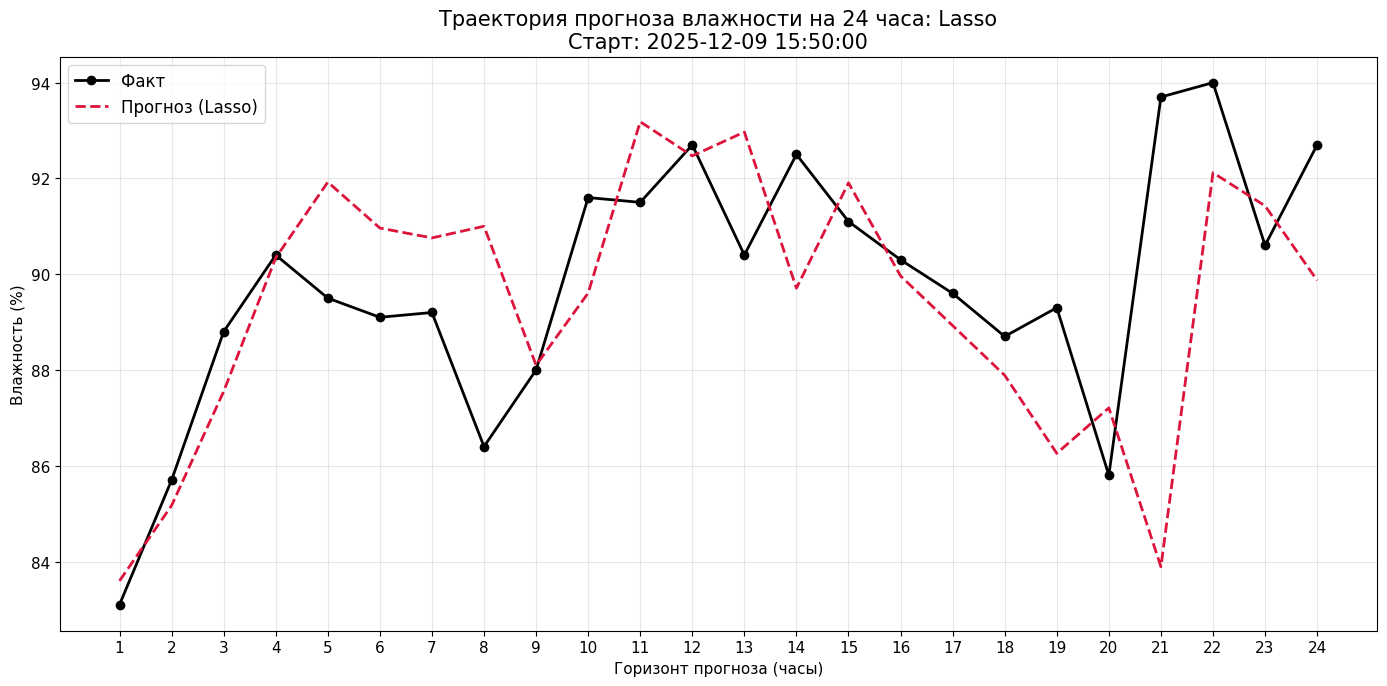

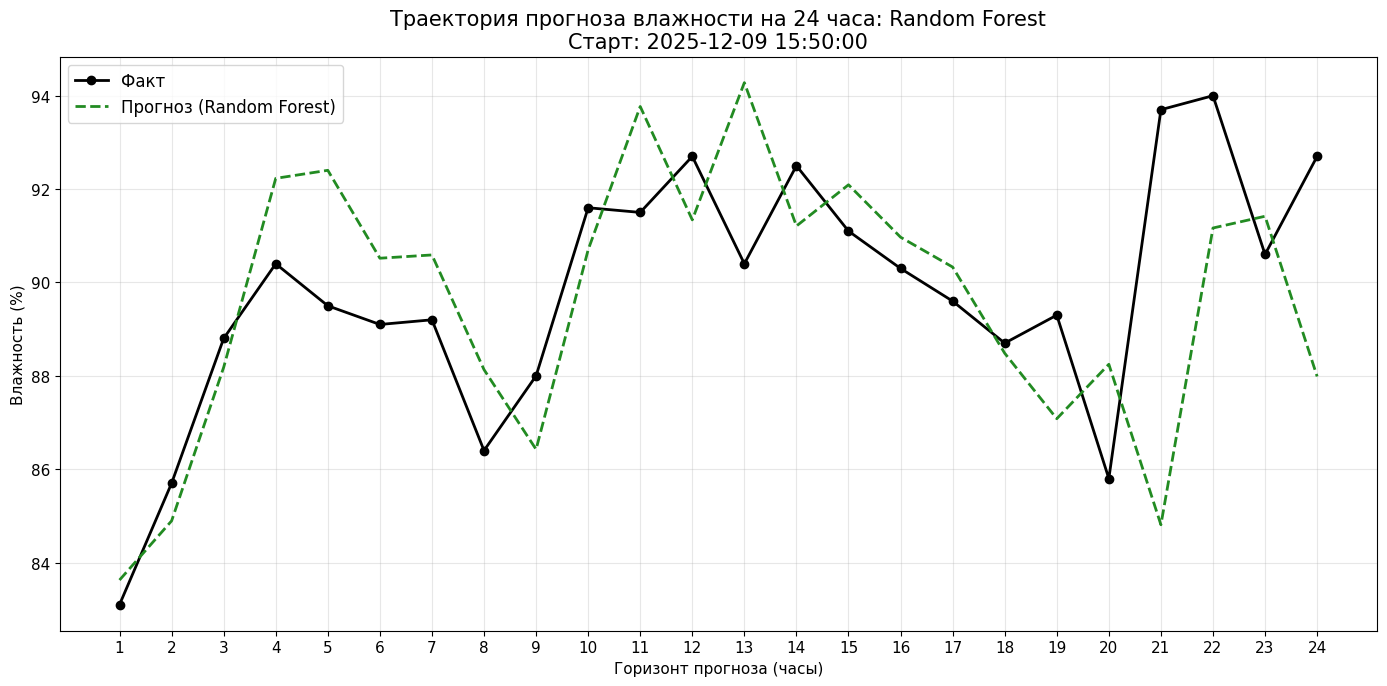

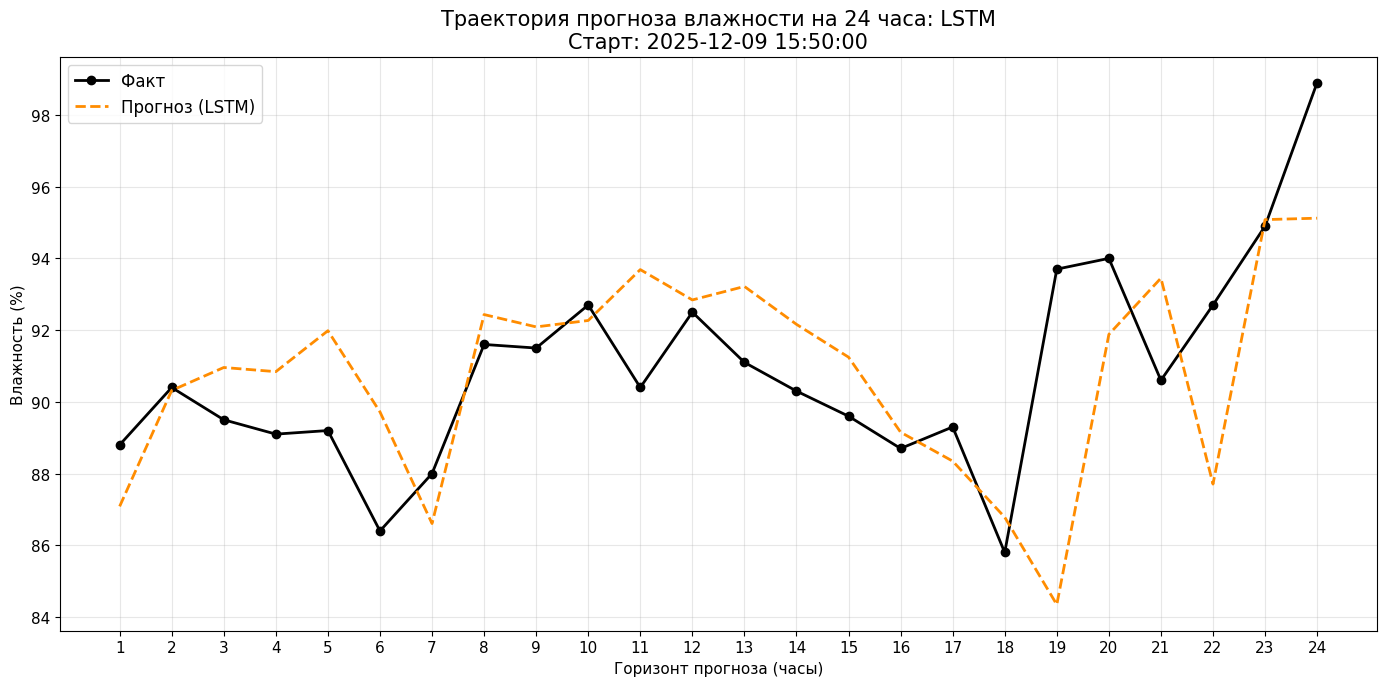

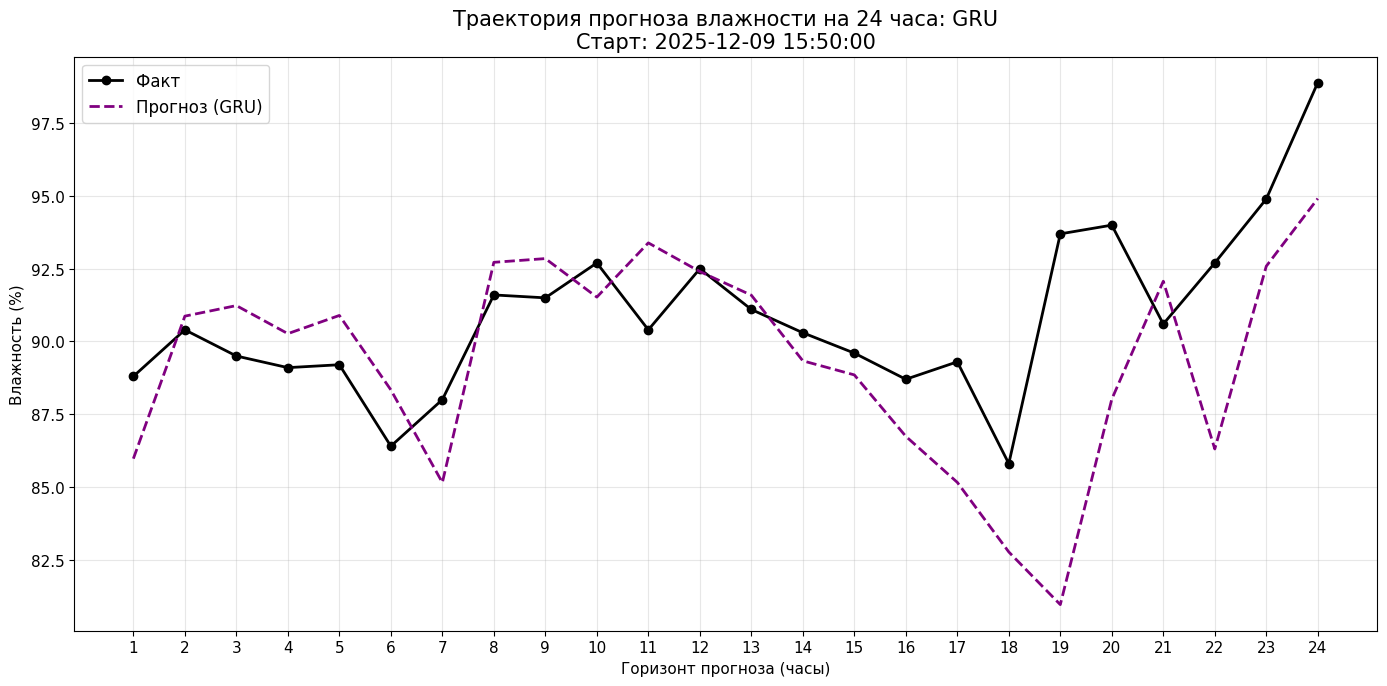

In [102]:
model_colors = {'Lasso': 'crimson', 'Random Forest': 'forestgreen',
                'LSTM': 'darkorange', 'GRU': 'purple'}

np.random.seed(42)
sample_idx = np.random.randint(0, min(len(v['pred_24h']) for v in results.values()))
hours = list(range(1, 25))
start_time = results["Lasso"]["dates"][sample_idx]

for name, res in results.items():
    fig, ax = plt.subplots(figsize=(14, 7))
    
    ax.plot(hours, res['true_24h'][sample_idx], 
            'ko-', linewidth=2, markersize=6, label='Факт')
    
    ax.plot(hours, res['pred_24h'][sample_idx], 
            '--', color=model_colors[name], linewidth=2, markersize=5, label=f'Прогноз ({name})')
    
    ax.set_title(f'Траектория прогноза влажности на 24 часа: {name}\nСтарт: {start_time}', fontsize=15)
    ax.set_xlabel('Горизонт прогноза (часы)')
    ax.set_ylabel('Влажность (%)')
    ax.set_xticks(hours)
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()